<a href="https://colab.research.google.com/github/huynhphtloi/rgbd-object-understanding/blob/thanhtu_01/notebooks/colab_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RGB-D Class-Agnostic Instance Segmentation
## Depth-Based Measurement + Spatial-Relation Reasoning


Pipeline:
1. Download & inspect OCID  
2. Scene-level split → YOLO + COCO conversion  
3. Train class-agnostic YOLO-seg (1 class: *object*)  
4. Depth-based measurement (visible 3-D extent via PCA-OBB)  
5. Rule-based spatial relations (overlaps / in_front_of / occludes / likely_on_top_of)  
6. Evaluate segmentation · counting · measurement · relations  
7. Streamlit interactive demo (camera capture + upload)

> **Runtime:** GPU (T4 recommended). Drive is mounted so weights & outputs survive restarts.


In [1]:
# @title 1 · GPU check + Mount Drive
# Check GPU
import subprocess, sys
r = subprocess.run(["nvidia-smi","--query-gpu=name,memory.total",
                    "--format=csv,noheader"], capture_output=True, text=True)
print("GPU:", r.stdout.strip() if r.returncode==0 else "CPU only – training will be slow")

# Mount Google Drive (outputs persist across sessions)
from google.colab import drive
drive.mount("/content/drive")

import os
DRIVE_ROOT = "/content/drive/MyDrive/rgbd_project"
os.makedirs(DRIVE_ROOT, exist_ok=True)
print("Drive root:", DRIVE_ROOT)


GPU: Tesla T4, 15360 MiB
Mounted at /content/drive
Drive root: /content/drive/MyDrive/rgbd_project


In [2]:
# @title 2 · Install dependencies
%%capture
!pip install -q ultralytics open3d streamlit huggingface_hub pycocotools networkx pandas gdown
print("Dependencies installed.")


In [5]:
# @title 3 · Clone / mount project
import os, sys

REPO = "/content/rgbd-object-understanding"
GITHUB_URL = "https://github.com/huynhphtloi/rgbd-object-understanding"

if not os.path.isdir(REPO):
    # Option A: clone from GitHub (after you push the repo)
    !git clone {GITHUB_URL} {REPO}

    # Option B: copy from Drive if you uploaded the project folder there
    # !cp -r /content/drive/MyDrive/rgbd_project/rgbd-object-understanding {REPO}

    # Option C (fallback): recreate the src tree inline – runs the generator notebook
    # raise RuntimeError(
    #     "Set GITHUB_URL above and uncomment Option A, "
    #     "OR upload the project to Drive and uncomment Option B."
    # )

sys.path.insert(0, REPO)
os.chdir(REPO)
print("Working directory:", os.getcwd())


Cloning into '/content/rgbd-object-understanding'...
remote: Enumerating objects: 171, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 171 (delta 35), reused 167 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (171/171), 560.78 KiB | 14.02 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Working directory: /content/rgbd-object-understanding


In [9]:
# @title 4 · Download OCID dataset
import os, gdown, tarfile, shutil

RAW_OCID = "data/raw/ocid"
DRIVE_CACHE = "/content/drive/MyDrive/rgbd_project/OCID-dataset"

# ── If already cached in Drive, just symlink ──────────────────────────────
if os.path.isdir(DRIVE_CACHE) and len(os.listdir(DRIVE_CACHE)) > 10:
    if not os.path.exists(RAW_OCID):
        os.makedirs("data/raw", exist_ok=True)
        os.symlink(DRIVE_CACHE, RAW_OCID)
    print("Using cached OCID from Drive:", DRIVE_CACHE)
else:
    # ── Download from Google Drive backup ───────────────────────────────
    GDRIVE_ID = "1mR_YcmfKqV4R_E6xMt8-yDjLk10w2-fo"
    TMP_DIR = "/content/OCID_raw"

    print("Downloading OCID from Google Drive backup (~1.5 GB) ...")
    gdown.download_folder(id=GDRIVE_ID, output=TMP_DIR, quiet=False, resume=True)

    # Extract .tar.gz if exists
    archive_path = os.path.join(TMP_DIR, "OCID-dataset.tar.gz")
    if os.path.isfile(archive_path):
        print("Extracting dataset...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=TMP_DIR)

    # Move the extracted 'OCID-dataset' content to RAW_OCID
    extracted_path = os.path.join(TMP_DIR, "OCID-dataset")
    os.makedirs(RAW_OCID, exist_ok=True)
    if os.path.isdir(extracted_path):
        for item in os.listdir(extracted_path):
            shutil.move(os.path.join(extracted_path, item), os.path.join(RAW_OCID, item))

    # Cache to Drive for future sessions
    if not os.path.isdir(DRIVE_CACHE):
        shutil.copytree(RAW_OCID, DRIVE_CACHE)
        print("Cached to Drive for future sessions.")

print("OCID root:", os.path.abspath(RAW_OCID))

Retrieving folder contents


Processing file 18o_ZIKgQoqT_GpJASqHZnf8DQP1AjUK4 OCID-dataset.tar.gz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=18o_ZIKgQoqT_GpJASqHZnf8DQP1AjUK4
From (redirected): https://drive.google.com/uc?id=18o_ZIKgQoqT_GpJASqHZnf8DQP1AjUK4&confirm=t&uuid=a60fdae5-4863-4093-9283-3c3b5ca55e49
To: /content/OCID_raw/OCID-dataset.tar.gz
100%|██████████| 6.82G/6.82G [01:45<00:00, 64.7MB/s]
Download completed
/tmp/ipykernel_626/2357662747.py:26: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=TMP_DIR)


Extracting dataset...
OCID root: /content/rgbd-object-understanding/data/raw/ocid


In [11]:
# @title 5 · Inspect OCID (depth unit, intrinsics, label ids)
import subprocess, sys, os, json

# Ensure output directory exists
os.makedirs("outputs/metrics", exist_ok=True)

# Fix: OCID dataset usually has subfolders like ARID10, ARID20, etc.
# The script expects the root that contains these sequence folders.
root_dir = "data/raw/ocid"

print(f"Checking structure in {root_dir}...")
if os.path.exists(root_dir):
    print("Contents:", os.listdir(root_dir)[:5])

result = subprocess.run(
    [sys.executable, "-m", "src.data.inspect_ocid",
     "--root", root_dir,
     "--samples", "100",
     "--out", "outputs/metrics/ocid_inspection.json"],
    capture_output=True, text=True
)

if result.stdout:
    print(result.stdout)

if result.returncode != 0:
    print("ERROR during inspection:")
    print(result.stderr[-2000:])

# Show the inspection report
inspection_file = "outputs/metrics/ocid_inspection.json"
if os.path.exists(inspection_file):
    with open(inspection_file) as f:
        report = json.load(f)

    print("\n=== INSPECTION SUMMARY ===")
    print(f"  Frames : {report['n_frames']}")
    print(f"  Scenes : {report['n_scenes']}")
    print(f"  Depth  : {report['depth_nonzero_range']}  ->  scale={report['recommended_depth_scale']}")
    print(f"  Sizes  : {report['image_sizes']}")
    print(f"  Objects/frame: {report['objects_per_frame']}")
    print("\nVerify the depth scale and check which label ids are background/plane.")
    print("Default assumption: ids 0,1 are bg/plane. If wrong, pass --bg-labels to convert scripts.")
else:
    print(f"\nError: {inspection_file} was not created.")
    print("Please ensure 'data/raw/ocid' contains sequence folders (e.g., ARID20, etc.)")

Checking structure in data/raw/ocid...
Contents: ['YCB10', 'OCID-dataset.tar.gz', 'ARID10', 'ARID20']
Frames: 2390   Scenes (sequences): 178

--- Depth ---
  dtype(s): ['uint16']
  nonzero range: [519.0, 2226.0]
  likely unit: millimetres  ->  recommended depth_scale = 0.001

--- Image sizes ---
  640x480: 100

--- Top label ids (by pixel count) ---
  id 1: 15695589 px (bg/plane?)
  id 2: 8272346 px
  id 0: 3534645 px (bg/plane?)
  id 3: 602408 px
  id 4: 543705 px
  id 5: 354077 px
  id 7: 343351 px
  id 6: 318487 px
  id 8: 185606 px
  id 11: 182876 px
  id 9: 122984 px
  id 10: 97019 px
  NOTE: confirm which low ids are background/support-plane vs objects,
        then pass --bg-labels to the conversion scripts accordingly.

--- Objects per frame (sampled) ---
  min 1  mean 7.8  max 21

Report written to outputs/metrics/ocid_inspection.json


=== INSPECTION SUMMARY ===
  Frames : 2390
  Scenes : 178
  Depth  : [519.0, 2226.0]  ->  scale=0.001
  Sizes  : {'640x480': 100}
  Objects/fr

In [12]:
# @title 6 · Scene-level split + YOLO + COCO conversion
import subprocess, sys, json

# ── Scene-level split (no leakage between incremental sequences) ───────────
r = subprocess.run(
    [sys.executable, "-m", "src.data.split_by_scene",
     "--root", "data/raw/ocid",
     "--out", "data/processed/splits.json",
     "--ratios", "0.70", "0.15", "0.15",
     "--seed", "42"],
    capture_output=True, text=True)
print(r.stdout); print(r.stderr[-500:] if r.returncode else "")

with open("data/processed/splits.json") as f:
    s = json.load(f)
for sp in ("train","val","test"):
    print(f"  {sp}: {len(s['frames'][sp])} frames  ({len(s['scenes'][sp])} scenes)")

# ── YOLO conversion (polygons, 1 class: object) ───────────────────────────
r = subprocess.run(
    [sys.executable, "-m", "src.data.convert_ocid_to_yolo",
     "--splits", "data/processed/splits.json",
     "--out", "data/processed",
     "--bg-labels", "0", "1",
     "--min-area", "200",
     "--link"],           # symlink images to save disk
    capture_output=True, text=True)
print(r.stdout); print(r.stderr[-500:] if r.returncode else "")

# ── COCO conversion (for mask AP evaluation) ──────────────────────────────
r = subprocess.run(
    [sys.executable, "-m", "src.data.convert_ocid_to_coco",
     "--splits", "data/processed/splits.json",
     "--out", "data/processed",
     "--bg-labels", "0", "1",
     "--min-area", "200"],
    capture_output=True, text=True)
print(r.stdout); print(r.stderr[-500:] if r.returncode else "")

print("Conversion done.")


Scenes  -> train 125, val 27, test 26
Frames  -> train 1763, val 315, test 312
Wrote data/processed/splits.json


  train: 1763 frames  (125 scenes)
  val: 315 frames  (27 scenes)
  test: 312 frames  (26 scenes)
[train] 1763 images, 15690 instance polygons
[val] 315 images, 2299 instance polygons
[test] 312 images, 2324 instance polygons

Done. Point config/dataset.yaml `path` at /content/rgbd-object-understanding/data/processed


[train] 1763 images, 14750 annotations -> data/processed/coco_annotations/train.json
[val] 315 images, 2155 annotations -> data/processed/coco_annotations/val.json
[test] 312 images, 2202 annotations -> data/processed/coco_annotations/test.json


Conversion done.


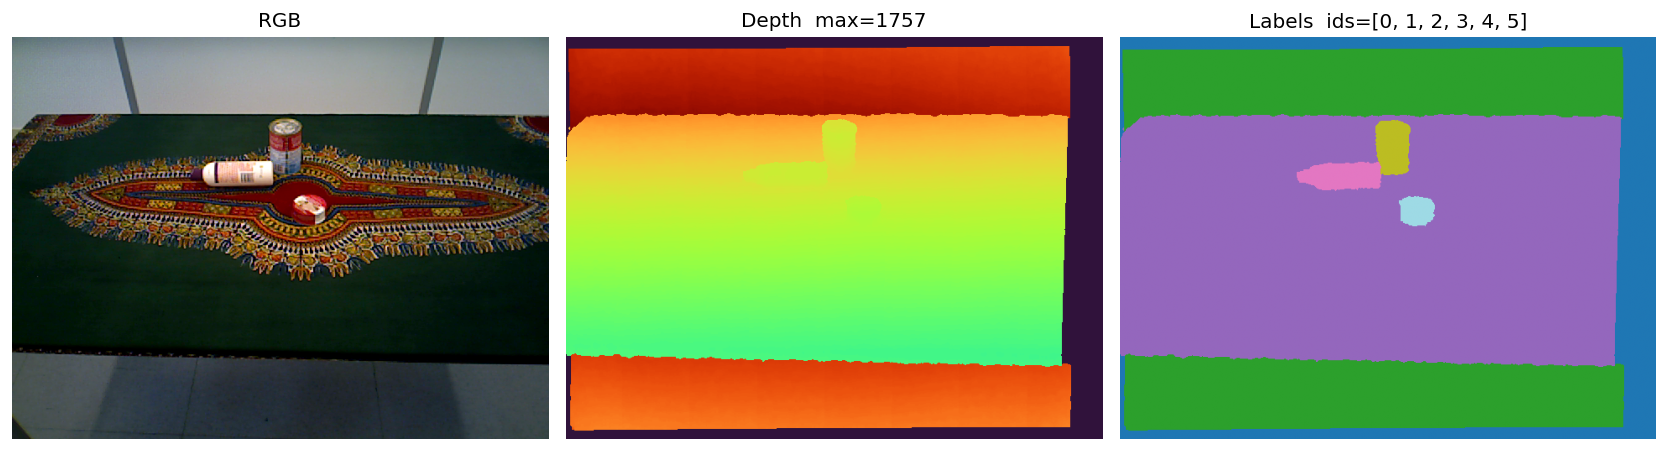

Sample verified. Check label ids above to confirm bg/plane ids (default: 0,1)


In [14]:
# @title 7 · Verify dataset sample (RGB / depth / label alignment)
import glob, cv2, numpy as np, os
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt, matplotlib.patches as patches
from IPython.display import display
from PIL import Image

# Load one sample to confirm RGB/depth/label alignment
from src.data.ocid_common import find_frames, load_label
frames = find_frames("data/raw/ocid")
if not frames:
    raise RuntimeError("No frames found — check data/raw/ocid structure")

fr = frames[len(frames)//2]   # pick a mid-sequence frame
rgb   = cv2.cvtColor(cv2.imread(fr.rgb),  cv2.COLOR_BGR2RGB)
depth = cv2.imread(fr.depth, cv2.IMREAD_UNCHANGED).astype(np.float32)
label = load_label(fr.label)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(rgb);  axes[0].set_title("RGB")
axes[1].imshow(depth, cmap="turbo"); axes[1].set_title(f"Depth  max={depth.max():.0f}")
axes[2].imshow(label, cmap="tab20"); axes[2].set_title(f"Labels  ids={np.unique(label).tolist()}")
for ax in axes: ax.axis("off")
plt.tight_layout()

# Fix: Create directory if it doesn't exist
os.makedirs("outputs/figures", exist_ok=True)

path = "outputs/figures/dataset_sample.png"
plt.savefig(path, dpi=120, bbox_inches="tight")
display(Image.open(path))
plt.close()
print("Sample verified. Check label ids above to confirm bg/plane ids (default: 0,1)")

Using depth scale: 0.001  (1 raw unit = 0.1 cm)
Point cloud: 265426 points
Z range: [0.692, 1.736] m  <- should be ~0.3–2.5 m for tabletop
If Z range looks wrong (e.g. 0.001–0.003), the depth scale is incorrect.


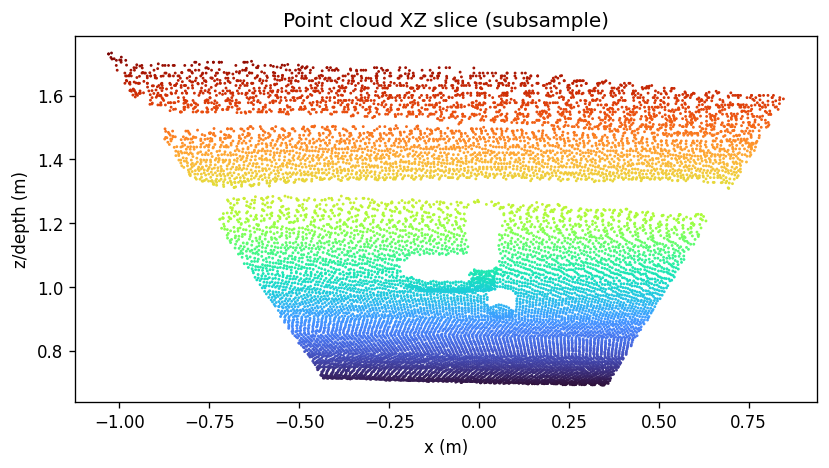

In [15]:
# @title 8 · Depth sanity check (scale + intrinsics)
import numpy as np, cv2, json
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from src.data.ocid_common import find_frames
from src.depth.depth_utils import CameraIntrinsics, to_metres, backproject
from src.depth.pointcloud import remove_statistical_outliers

with open("outputs/metrics/ocid_inspection.json") as f:
    insp = json.load(f)
DEPTH_SCALE = insp["recommended_depth_scale"]
print(f"Using depth scale: {DEPTH_SCALE}  (1 raw unit = {DEPTH_SCALE*100:.1f} cm)")

frames = find_frames("data/raw/ocid")
fr = frames[len(frames)//2]
depth_raw = cv2.imread(fr.depth, cv2.IMREAD_UNCHANGED).astype(np.float32)
depth_m   = to_metres(depth_raw, DEPTH_SCALE, min_depth_m=0.1, max_depth_m=5.0)

# Default OCID intrinsics (ASUS Xtion 640x480)
intr = CameraIntrinsics(fx=525, fy=525, cx=319.5, cy=239.5, width=640, height=480)
points, _ = backproject(depth_m, intr)
points, _  = remove_statistical_outliers(points)

print(f"Point cloud: {len(points)} points")
print(f"Z range: [{points[:,2].min():.3f}, {points[:,2].max():.3f}] m  <- should be ~0.3–2.5 m for tabletop")
print(f"If Z range looks wrong (e.g. 0.001–0.003), the depth scale is incorrect.")

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(points[::20, 0], points[::20, 2], s=0.5, c=points[::20, 2], cmap="turbo")
ax.set_xlabel("x (m)"); ax.set_ylabel("z/depth (m)")
ax.set_title("Point cloud XZ slice (subsample)")
plt.tight_layout()
plt.savefig("outputs/figures/depth_sanity.png", dpi=120, bbox_inches="tight")
display(Image.open("outputs/figures/depth_sanity.png"))
plt.close()


In [16]:
# @title 9 · Patch dataset.yaml with absolute path
import os, yaml

# Update dataset.yaml to use the absolute processed path inside Colab
cfg_path = "config/dataset.yaml"
with open(cfg_path) as f:
    ds = yaml.safe_load(f)

ds["path"] = os.path.abspath("data/processed")
with open(cfg_path, "w") as f:
    yaml.dump(ds, f)

print("dataset.yaml updated:")
print(yaml.dump(ds))


dataset.yaml updated:
names:
  0: object
path: /content/rgbd-object-understanding/data/processed
test: images/test
train: images/train
val: images/val



In [ ]:
# @title 10 · Train YOLO-seg (class-agnostic, 1 class: object)
import subprocess, sys, shutil, os

# Choose model size: n (fast) | s | m (better accuracy, slower)
MODEL = "yolov8n-seg.pt"  # @param ["yolov8n-seg.pt","yolov8s-seg.pt","yolov8m-seg.pt"]
EPOCHS = 100              # @param {type:"integer"}
BATCH  = 8               # @param {type:"integer"}
IMGSZ  = 640             # @param {type:"integer"}

r = subprocess.run(
    [sys.executable, "-m", "src.segmentation.train_yolo",
     "--model", MODEL,
     "--epochs", str(EPOCHS),
     "--batch",  str(BATCH),
     "--imgsz",  str(IMGSZ),
     "--device", "0"],
    capture_output=False   # stream output directly
)
print("Training exit code:", r.returncode)

# Copy best weights to Drive for persistence
best = "outputs/models/rgb_yolo_seg_baseline/weights/best.pt"
if os.path.isfile(best):
    dst = "/content/drive/MyDrive/rgbd_project/best.pt"
    shutil.copy(best, dst)
    print(f"Best weights saved to Drive: {dst}")


In [ ]:
# @title 11 · Training curves
import glob
from IPython.display import display
from PIL import Image

results_dir = "outputs/models/rgb_yolo_seg_baseline"
for fig_name in ("results.png", "confusion_matrix.png"):
    path = f"{results_dir}/{fig_name}"
    if os.path.isfile(path):
        print(fig_name)
        display(Image.open(path))


In [ ]:
# @title 12 · Evaluate segmentation (mask mAP)
import subprocess, sys, json

r = subprocess.run(
    [sys.executable, "-m", "src.evaluation.eval_segmentation",
     "--weights", "outputs/models/rgb_yolo_seg_baseline/weights/best.pt",
     "--data",    "config/dataset.yaml",
     "--split",   "test",
     "--out",     "outputs/metrics/segmentation_metrics.json"],
    capture_output=True, text=True)
print(r.stdout[-3000:])
if r.returncode != 0:
    print("STDERR:", r.stderr[-1000:])

with open("outputs/metrics/segmentation_metrics.json") as f:
    m = json.load(f)

print("\n=== SEGMENTATION METRICS (test split) ===")
for k, v in m.items():
    print(f"  {k}: {v:.4f}")


In [ ]:
# @title 13 · Run pipeline on test set (counting CSV + scenes)
import os, sys, json, yaml
import cv2, numpy as np, pandas as pd
from tqdm import tqdm

from src.data.ocid_common import find_frames, load_label, object_instance_ids
from src.depth.depth_utils import CameraIntrinsics, to_metres, load_depth
from src.data.ocid_common import DEFAULT_INTRINSICS
from src.pipeline import Pipeline

with open("config/demo.yaml") as f:
    cfg = yaml.safe_load(f)
with open("data/processed/splits.json") as f:
    split_data = json.load(f)
with open("outputs/metrics/ocid_inspection.json") as fi:
    insp = json.load(fi)

DEPTH_SCALE = insp["recommended_depth_scale"]
cfg["depth"]["depth_scale"] = DEPTH_SCALE
intr = CameraIntrinsics.from_dict(DEFAULT_INTRINSICS)
frames_idx = {fr.key: fr for fr in find_frames(split_data["root"])}
pipe = Pipeline(cfg)

rows, scene_list = [], []
test_keys = split_data["frames"]["test"][:200]  # cap at 200 for speed; remove cap for full eval

for key in tqdm(test_keys, desc="Running pipeline on test set"):
    fr = frames_idx.get(key)
    if fr is None:
        continue
    rgb     = cv2.imread(fr.rgb, cv2.IMREAD_COLOR)
    d_raw   = load_depth(fr.depth)
    depth_m = to_metres(d_raw, DEPTH_SCALE, min_depth_m=0.1, max_depth_m=5.0)
    gt_cnt  = len(object_instance_ids(load_label(fr.label)))

    res = pipe.run(rgb, depth_m, intr, image_name=key)
    scene_list.append(res.scene)
    rows.append({
        "image": key,
        "gt_count": gt_cnt,
        "rgb_only_count": res.counts["rgb_only_count"],
        "depth_filtered_count": res.counts["depth_filtered_count"],
    })

os.makedirs("outputs/metrics", exist_ok=True)
pd.DataFrame(rows).to_csv("outputs/metrics/counting.csv", index=False)
print(f"Processed {len(rows)} test frames. Saved outputs/metrics/counting.csv")


In [ ]:
# @title 14 · Counting ablation (RGB-only vs depth-filtered)
import subprocess, sys, json

r = subprocess.run(
    [sys.executable, "-m", "src.evaluation.eval_counting",
     "--pred", "outputs/metrics/counting.csv",
     "--out",  "outputs/metrics/counting_ablation.json"],
    capture_output=True, text=True)
print(r.stdout)

with open("outputs/metrics/counting_ablation.json") as f:
    c = json.load(f)

import pandas as pd
rows = []
for mode, m in c.items():
    rows.append({"mode": mode, **m})
df = pd.DataFrame(rows).set_index("mode")
print("\n=== COUNTING ABLATION ===")
print(df.round(3).to_string())
print("\nNote: if depth_filtered ≈ rgb_only, that is a valid null result –")
print("RGB NMS already handled duplicates; depth filtering removes depth-invalid masks only.")


In [ ]:
# @title 15 · Measurement evaluation (synthetic sanity check)
# Measurement evaluation using the synthetic scene as a quick sanity check.
# Replace with your self-captured measurement_gt.csv for real evaluation.
import subprocess, sys, json, os

os.makedirs("outputs/demo_results", exist_ok=True)
r = subprocess.run(
    [sys.executable, "-m", "src.run_pipeline",
     "--synthetic",
     "--out", "outputs/demo_results"],
    capture_output=True, text=True)
print(r.stdout)

with open("outputs/demo_results/measurement_eval.json") as f:
    rows = json.load(f)

import pandas as pd
matched = [r for r in rows if r.get("matched")]
df = pd.DataFrame(matched)
print("\n=== MEASUREMENT ACCURACY (synthetic ground truth) ===")
cols = ["gt_id","gt_dims_cm","pred_dims_cm","abs_err_cm","mean_abs_err_cm","visibility"]
print(df[cols].to_string(index=False))
if len(matched):
    import numpy as np
    print(f"\nOverall mean abs error: {np.mean(df['mean_abs_err_cm']):.2f} cm  "
          f"over {len(matched)}/{len(rows)} objects")
print("\nFor REAL measurement eval, place your CSV at:")
print("  data/samples/self_captured_measurement_gt/measurement_gt.csv")
print("  (columns: object_id, real_width_cm, real_height_cm, real_depth_cm, visibility)")
print("Then run: python3 -m src.evaluation.eval_measurement --gt <gt.csv> --pred <pred.csv>")


## 16 · Spatial-relation evaluation

**Manual annotation needed.** Use the relation annotation guide:

1. Pick 100–200 object pairs from the test set (we suggest taking the output
   `scene.json` from Cell 13 and sampling pairs with overlapping bboxes).
2. Label each pair with one of:  
   `in_front_of / behind / overlaps / occludes / partially_occluded_by / likely_on_top_of / none`
3. Save as `data/samples/relation_labels.csv` with columns `subject, object, relation`.
4. Ask one teammate to label 30–50 pairs → `data/samples/relation_labels_a2.csv`.
5. Run the cell below.

> **Rule:** label FIRST, tune rule thresholds LATER. Never tune on the eval set.


In [ ]:
# @title 16 · Evaluate spatial relations (requires manual annotation)
import os, subprocess, sys

GT_CSV = "data/samples/relation_labels.csv"
A2_CSV = "data/samples/relation_labels_a2.csv"   # optional second annotator

if not os.path.isfile(GT_CSV):
    print("GT annotations not yet created. Follow the instructions in the Markdown cell above.")
else:
    cmd = [sys.executable, "-m", "src.evaluation.eval_relations",
           "--gt",   GT_CSV,
           "--pred", "outputs/metrics/relation_predictions.csv",
           "--out",  "outputs/metrics/relation_metrics.json"]
    if os.path.isfile(A2_CSV):
        cmd += ["--annotator2", A2_CSV]
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(r.stdout)
    from IPython.display import display
    from PIL import Image
    cm_path = "outputs/metrics/relation_metrics_confusion.png"
    if os.path.isfile(cm_path):
        display(Image.open(cm_path))


In [ ]:
# @title 17 · Qualitative results (6 test frames)
import os, cv2, yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
from IPython.display import display
from PIL import Image
from src.data.ocid_common import find_frames
from src.depth.depth_utils import CameraIntrinsics, to_metres, load_depth
from src.data.ocid_common import DEFAULT_INTRINSICS as INTR_DICT
from src.pipeline import Pipeline
from src.visualization.draw_masks import overlay_instances
from src.visualization.draw_depth import colorize_depth
from src.visualization.draw_obb import draw_dimension_boxes
from src.visualization.draw_graph import render_relation_graph
import json, yaml

with open("config/demo.yaml") as f: cfg = yaml.safe_load(f)
with open("outputs/metrics/ocid_inspection.json") as f:
    insp = json.load(f)
cfg["depth"]["depth_scale"] = insp["recommended_depth_scale"]

frames = find_frames("data/raw/ocid")
intr   = CameraIntrinsics.from_dict(INTR_DICT)
pipe   = Pipeline(cfg)
os.makedirs("outputs/figures", exist_ok=True)

for i, fr in enumerate(frames[::len(frames)//6][:6]):
    rgb   = cv2.imread(fr.rgb, cv2.IMREAD_COLOR)
    d_raw = load_depth(fr.depth)
    depth_m = to_metres(d_raw, cfg["depth"]["depth_scale"], 0.1, 5.0)
    res = pipe.run(rgb, depth_m, intr, image_name=f"sample_{i}")

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].imshow(cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)); ax[0].set_title("RGB")
    ax[1].imshow(cv2.cvtColor(overlay_instances(rgb, res.instances), cv2.COLOR_BGR2RGB))
    ax[1].set_title(f"Masks (n={res.counts['depth_filtered_count']})")
    ax[2].imshow(cv2.cvtColor(draw_dimension_boxes(rgb, res.instances), cv2.COLOR_BGR2RGB))
    ax[2].set_title("Dimensions")
    for a in ax: a.axis("off")
    plt.tight_layout()
    path = f"outputs/figures/qualitative_{i}.png"
    plt.savefig(path, dpi=100, bbox_inches="tight"); plt.close()
    display(Image.open(path))
    print(f"  Relations: {[r['relation'] for r in res.scene['relations']]}")


In [ ]:
# @title 18 · Failure analysis gallery
# Show frames where count was most wrong (failure gallery)
import pandas as pd, cv2, os, yaml, json
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from src.data.ocid_common import find_frames

df = pd.read_csv("outputs/metrics/counting.csv")
df["err"] = (df["depth_filtered_count"] - df["gt_count"]).abs()
worst = df.nlargest(6, "err")

frames_idx = {fr.key: fr for fr in find_frames("data/raw/ocid")}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.ravel(), worst.iterrows()):
    fr = frames_idx.get(row["image"])
    if fr:
        rgb = cv2.cvtColor(cv2.imread(fr.rgb), cv2.COLOR_BGR2RGB)
        ax.imshow(rgb)
        ax.set_title(f"gt={int(row.gt_count)}  pred={int(row.depth_filtered_count)}", fontsize=9)
    ax.axis("off")
plt.suptitle("Worst counting failures", fontsize=13)
plt.tight_layout()
path = "outputs/figures/failure_gallery.png"
plt.savefig(path, dpi=100, bbox_inches="tight"); plt.close()
display(Image.open(path))


In [ ]:
# @title 19 · Launch Streamlit interactive demo
# The Streamlit demo lives in src/app/streamlit_app.py.
# Run it locally with:  streamlit run src/app/streamlit_app.py
# In Colab, expose it via a tunnel (e.g. localtunnel):
!npm install -g localtunnel -q
import os
os.chdir("/content/rgbd-object-understanding")
get_ipython().system_raw("streamlit run src/app/streamlit_app.py --server.port 8501 &")
!npx localtunnel --port 8501


In [ ]:
# @title 20 · Save all outputs to Google Drive
import shutil, os, datetime

stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
dst   = f"/content/drive/MyDrive/rgbd_project/run_{stamp}"
shutil.copytree("outputs", dst)
print(f"All outputs saved to Drive: {dst}")
print("Contents:")
for root, dirs, files in os.walk(dst):
    level = root.replace(dst,"").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        sz = os.path.getsize(os.path.join(root,f))
        print(f"{indent}  {f}  ({sz//1024} KB)")
